# Perfilado de Datos Crudos (Olist)

Análisis de calidad, tipos de datos y nulos inicial de las tablas crudas.

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import missingno as msno
from scipy.stats import skew

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga de Datasets Crudos

In [2]:
DATA_DIR = Path("../../data/raw")

customers = pd.read_parquet(DATA_DIR / "olist_customers_dataset.parquet")
orders = pd.read_parquet(DATA_DIR / "olist_orders_dataset.parquet")
payments = pd.read_parquet(DATA_DIR / "olist_order_payments_dataset.parquet")
reviews = pd.read_parquet(DATA_DIR / "olist_order_reviews_dataset.parquet")
order_items = pd.read_parquet(DATA_DIR / "olist_order_items_dataset.parquet")
products = pd.read_parquet(DATA_DIR / "olist_products_dataset.parquet")
sellers = pd.read_parquet(DATA_DIR / "olist_sellers_dataset.parquet")

print("Los 7 datasets crudos fueron cargados correctamente.")

Los 7 datasets crudos fueron cargados correctamente.


## 3. Exploración Inicial y Dimensiones

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "payments": payments,
    "reviews": reviews,
    "order_items": order_items,
    "products": products,
    "sellers": sellers
}

summary = []
for name, df in datasets.items():
    summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicated_rows": df.duplicated().sum(),
        "total_nulls": df.isna().sum().sum()
    })

display(pd.DataFrame(summary))

,dataset,rows,columns,duplicated_rows,total_nulls
0,customers,99441,5,0,0
1,orders,99441,8,0,4908
2,payments,103886,5,0,0
3,reviews,99224,7,0,145903
4,order_items,112650,7,0,0
5,products,32951,9,0,2448
6,sellers,3095,4,0,0


### Catálogos Auxiliares

Revisión rápida de productos y vendedores.

In [4]:
print("===== PRODUCTS HEAD =====")
display(products.head(3))
print("\n===== PRODUCTS INFO =====")
products.info()

print("\n===== SELLERS HEAD =====")
display(sellers.head(3))
print("\n===== SELLERS INFO =====")
sellers.info()

===== PRODUCTS HEAD =====


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



===== PRODUCTS INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB

===== SELLERS HEAD =====


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



===== SELLERS INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB


## 4. Análisis de Valores Nulos

In [5]:
for name, df in datasets.items():
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    if len(null_cols) > 0:
        print(f"\n===== NULLS IN {name.upper()} =====")
        display(pd.DataFrame({"Null Count": null_cols, "Proportion": null_cols / len(df)}))
    else:
        print(f"\n===== {name.upper()}: No contiene nulos =====")


===== CUSTOMERS: No contiene nulos =====

===== NULLS IN ORDERS =====


,Null Count,Proportion
order_delivered_customer_date,2965,0.029817
order_delivered_carrier_date,1783,0.017930
order_approved_at,160,0.001609



===== PAYMENTS: No contiene nulos =====

===== NULLS IN REVIEWS =====


,Null Count,Proportion
review_comment_title,87656,0.883415
review_comment_message,58247,0.587025



===== ORDER_ITEMS: No contiene nulos =====

===== NULLS IN PRODUCTS =====


,Null Count,Proportion
product_category_name,610,0.018512
product_name_lenght,610,0.018512
product_description_lenght,610,0.018512
product_photos_qty,610,0.018512
product_weight_g,2,0.000061
product_length_cm,2,0.000061
product_height_cm,2,0.000061
product_width_cm,2,0.000061



===== SELLERS: No contiene nulos =====


### Visualización de Completitud

Patrón de datos faltantes en productos y reviews.

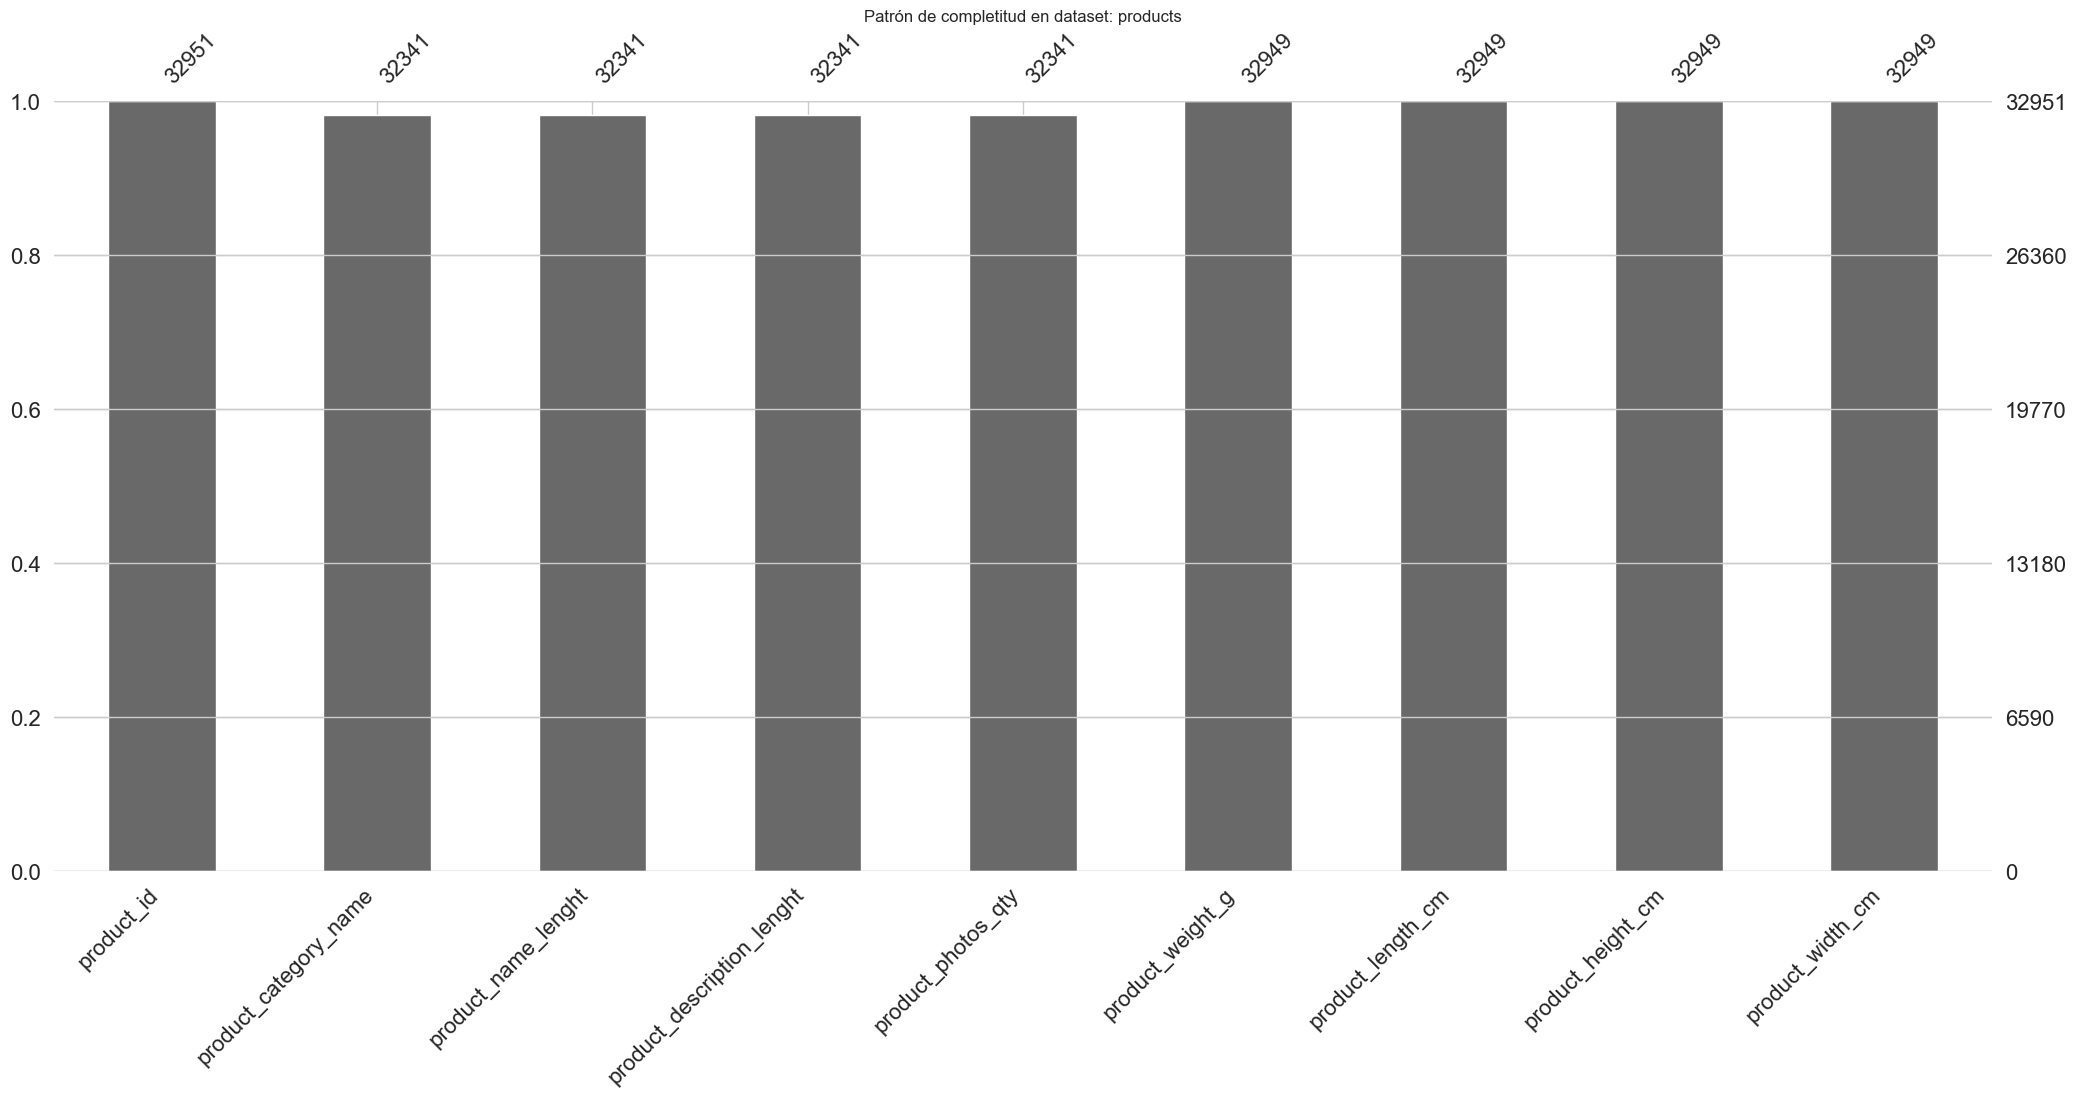

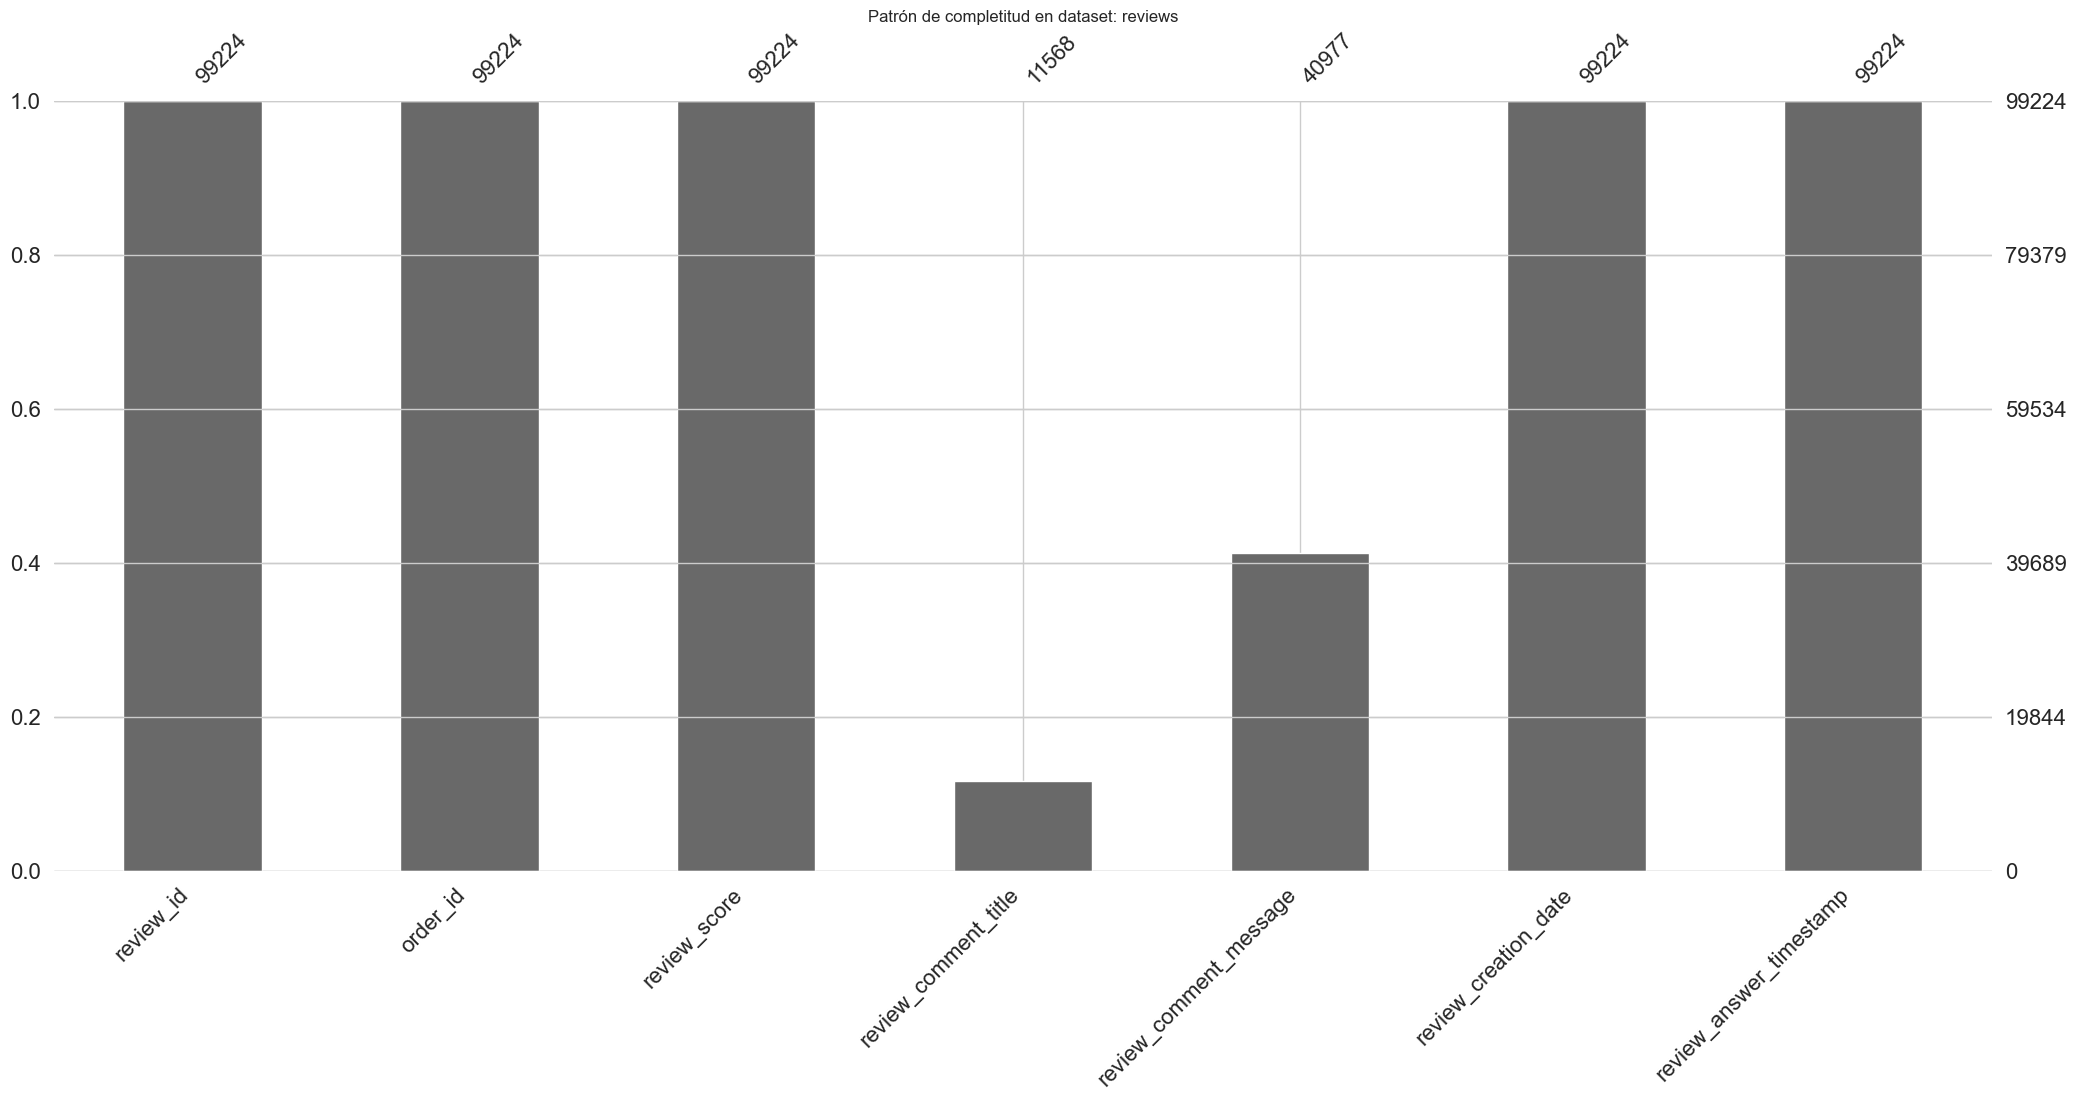

In [6]:
for name in ["products", "reviews"]:
    plt.figure(figsize=(10, 4))
    msno.bar(datasets[name])
    plt.title(f"Patrón de completitud en dataset: {name}")
    plt.show()

## 5. Integridad de Claves Primarias y Unicidad

In [7]:
print("===== Verificación de Unicidad de Claves =====")
print("customers (customer_id es único):", customers["customer_id"].is_unique)
print("orders (order_id es único):", orders["order_id"].is_unique)
print("products (product_id es único):", products["product_id"].is_unique)
print("sellers (seller_id es único):", sellers["seller_id"].is_unique)
print("order_items (order_id + order_item_id es único):", not order_items.duplicated(subset=["order_id", "order_item_id"]).any())

print("\n===== Total Clientes Únicos en customers =====")
print("customer_unique_id únicos:", customers["customer_unique_id"].nunique())

===== Verificación de Unicidad de Claves =====
customers (customer_id es único): True
orders (order_id es único): True
products (product_id es único): True
sellers (seller_id es único): True
order_items (order_id + order_item_id es único): True

===== Total Clientes Únicos en customers =====
customer_unique_id únicos: 96096


## 6. Auditoría de Consistencia Temporal

Validación del ciclo lógico de fechas de envío y entrega.

In [8]:
# convertir a datetime
df_temp = orders.copy()
date_cols = [
    "order_purchase_timestamp", "order_approved_at", 
    "order_delivered_carrier_date", "order_delivered_customer_date"
]
for col in date_cols:
    df_temp[col] = pd.to_datetime(df_temp[col])

# 1. Envío al transportista antes de compra
carrier_before_purchase = df_temp["order_delivered_carrier_date"] < df_temp["order_purchase_timestamp"]
# 2. Envío al transportista antes de aprobación del pago
carrier_before_approved = df_temp["order_delivered_carrier_date"] < df_temp["order_approved_at"]
# 3. Entrega al cliente antes del envío al transportista
delivered_before_carrier = df_temp["order_delivered_customer_date"] < df_temp["order_delivered_carrier_date"]
# 4. Entrega al cliente antes de la aprobación del pago
delivered_before_approved = df_temp["order_delivered_customer_date"] < df_temp["order_approved_at"]

print("===== Reporte de Inconsistencias Temporales =====")
print(f"Pedidos con envío al transportista anterior a la compra: {carrier_before_purchase.sum()}")
print(f"Pedidos con recogida de transportista anterior a la aprobación de pago: {carrier_before_approved.sum()}")
print(f"Pedidos entregados al cliente antes de recibirlos el transportista: {delivered_before_carrier.sum()}")
print(f"Pedidos entregados al cliente antes de la aprobación de pago: {delivered_before_approved.sum()}")

# Muestra de ejemplo de inconsistencia
if carrier_before_approved.sum() > 0:
    print("\nEjemplo de recogida de transportista previa a la aprobación del pago:")
    display(df_temp[carrier_before_approved][date_cols + ["order_id"]].head(3))

===== Reporte de Inconsistencias Temporales =====
Pedidos con envío al transportista anterior a la compra: 166
Pedidos con recogida de transportista anterior a la aprobación de pago: 1359
Pedidos entregados al cliente antes de recibirlos el transportista: 23
Pedidos entregados al cliente antes de la aprobación de pago: 61

Ejemplo de recogida de transportista previa a la aprobación del pago:


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_id
15,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,dcb36b511fcac050b97cd5c05de84dc3
64,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,688052146432ef8253587b930b01a06d
199,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19,58d4c4747ee059eeeb865b349b41f53a


## 7. Distribución del Estado de Órdenes

,Órdenes,Proporción
order_status,,
delivered,96478,0.970203
shipped,1107,0.011132
canceled,625,0.006285
unavailable,609,0.006124
invoiced,314,0.003158
processing,301,0.003027
created,5,0.000050
approved,2,0.000020


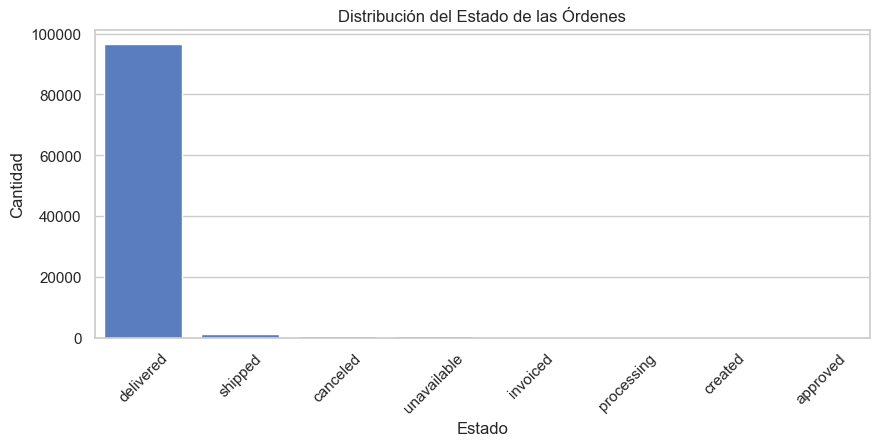

In [9]:
order_status_counts = orders["order_status"].value_counts()
order_status_props = orders["order_status"].value_counts(normalize=True)
display(pd.DataFrame({"Órdenes": order_status_counts, "Proporción": order_status_props}))

plt.figure(figsize=(10, 4))
sns.countplot(data=orders, x="order_status", order=order_status_counts.index)
plt.title("Distribución del Estado de las Órdenes")
plt.xlabel("Estado")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

## 8. Asimetría Financiera (Precios y Fletes)

Análisis de la distribución logarítmica de precios y fletes para justificar el uso de percentiles.

Asimetría (Skewness) de Precios: 7.9231
Asimetría (Skewness) de Fletes: 5.6398


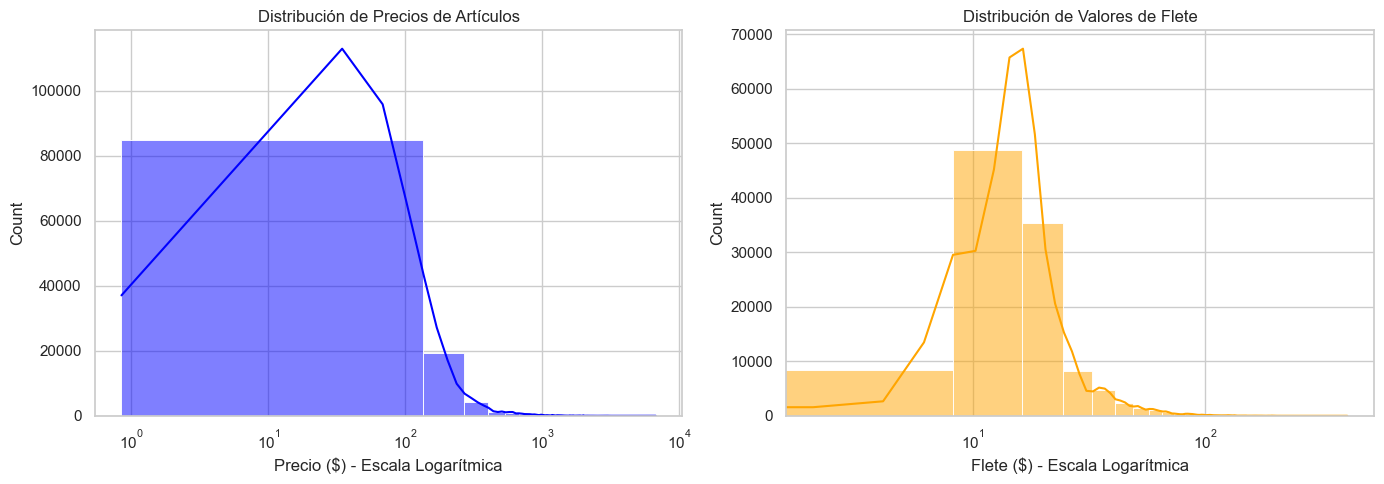

In [10]:
price_skew = skew(order_items["price"].dropna())
freight_skew = skew(order_items["freight_value"].dropna())

print(f"Asimetría (Skewness) de Precios: {price_skew:.4f}")
print(f"Asimetría (Skewness) de Fletes: {freight_skew:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Precios
sns.histplot(data=order_items, x="price", kde=True, ax=axes[0], bins=50, color="blue")
axes[0].set_title("Distribución de Precios de Artículos")
axes[0].set_xlabel("Precio ($)")
axes[0].set_xscale("log")
axes[0].set_xlabel("Precio ($) - Escala Logarítmica")

# Histograma de Fletes
sns.histplot(data=order_items, x="freight_value", kde=True, ax=axes[1], bins=50, color="orange")
axes[1].set_title("Distribución de Valores de Flete")
axes[1].set_xlabel("Flete ($)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Flete ($) - Escala Logarítmica")

plt.tight_layout()
plt.show()

### Conclusión sobre el Target:
La asimetría positiva extrema (>7) indica que el gasto está concentrado en una cola larga. Esto justifica usar un percentil robusto (percentil 80) para definir el target `is_premium`.

## 9. Detección de Anomalías Cuantitativas

Identificación de valores <= 0 en fletes y pagos.

In [11]:
print("===== Resumen de Variables Financieras =====")
display(order_items[["price", "freight_value"]].describe().T)
display(payments[["payment_value"]].describe().T)

print("\n===== Detección de Valores <= 0 =====")
print("Items con precio <= 0:", (order_items["price"] <= 0).sum())
print("Items con flete < 0:", (order_items["freight_value"] < 0).sum())
print("Pagos con valor <= 0:", (payments["payment_value"] <= 0).sum())

# investigar pagos con valor <= 0
if (payments["payment_value"] <= 0).sum() > 0:
    print("\nDetalle de pagos con valor <= 0 (Ejemplos de vouchers o cupones de descuento completo):")
    display(payments[payments["payment_value"] <= 0].head(5))

===== Resumen de Variables Financieras =====


,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68


,count,mean,std,min,25%,50%,75%,max
payment_value,103886.0,154.10038,217.494064,0.0,56.79,100.0,171.8375,13664.08



===== Detección de Valores <= 0 =====
Items con precio <= 0: 0
Items con flete < 0: 0
Pagos con valor <= 0: 9

Detalle de pagos con valor <= 0 (Ejemplos de vouchers o cupones de descuento completo):


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0


## 10. Productos, Categorías y Montos de Venta
Análisis de productos vendidos, cobertura de categorías y facturación por producto/categoría.

In [ ]:
# Traducción de categorías (PT -> EN)
category_translation = pd.read_parquet(DATA_DIR / "product_category_name_translation.parquet")

products_enriched = products.merge(category_translation, on="product_category_name", how="left")

total_products = products_enriched["product_id"].nunique()
categories_pt = products_enriched["product_category_name"].dropna().nunique()
categories_en = products_enriched["product_category_name_english"].dropna().nunique()
products_without_category = products_enriched["product_category_name"].isna().sum()

print(f"Productos únicos: {total_products:,}")
print(f"Categorías (PT, no nulas): {categories_pt}")
print(f"Categorías (EN traducidas, no nulas): {categories_en}")
print(f"Productos sin categoría: {products_without_category:,}")

categories_catalog = (
    products_enriched[["product_category_name", "product_category_name_english"]]
    .drop_duplicates()
    .fillna("SIN_CATEGORIA")
    .sort_values(["product_category_name", "product_category_name_english"])
    .reset_index(drop=True)
)

display(categories_catalog.head(20))


In [ ]:
# Ventas por producto (monto bruto = sum(price))
product_sales = (
    order_items.groupby("product_id", as_index=False)
    .agg(
        qty=("order_item_id", "count"),
        gross_revenue=("price", "sum"),
        freight_revenue=("freight_value", "sum"),
    )
)
product_sales["total_revenue_incl_freight"] = product_sales["gross_revenue"] + product_sales["freight_revenue"]

product_sales_detail = product_sales.merge(
    products_enriched[["product_id", "product_category_name", "product_category_name_english"]],
    on="product_id",
    how="left",
)

top_products_revenue = product_sales_detail.sort_values("gross_revenue", ascending=False).head(15)
display(top_products_revenue)


In [ ]:
# Ventas agregadas por categoría
category_sales = (
    product_sales_detail.groupby(["product_category_name", "product_category_name_english"], dropna=False, as_index=False)
    .agg(
        products_sold=("product_id", "nunique"),
        qty=("qty", "sum"),
        gross_revenue=("gross_revenue", "sum"),
    )
    .sort_values("gross_revenue", ascending=False)
)

display(category_sales.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(data=category_sales.head(10), x="gross_revenue", y="product_category_name_english", palette="viridis")
plt.title("Top 10 categorías por monto bruto de venta")
plt.xlabel("Monto bruto (sum price)")
plt.ylabel("Categoría (EN)")
plt.tight_layout()
plt.show()


## 11. Recompra de Clientes (Más de 1 Compra)
Medición del porcentaje de clientes que repiten compra, con segmentación por cohorte y por mes calendario.

In [ ]:
orders_customers = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left",
).copy()
orders_customers["order_purchase_timestamp"] = pd.to_datetime(
    orders_customers["order_purchase_timestamp"], errors="coerce"
)
orders_customers = orders_customers.dropna(subset=["customer_unique_id", "order_purchase_timestamp"])

orders_per_customer = (
    orders_customers.groupby("customer_unique_id")["order_id"].nunique()
)

total_customers = orders_per_customer.shape[0]
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = repeat_customers / total_customers * 100

print(f"Clientes únicos: {total_customers:,}")
print(f"Clientes con más de 1 compra: {repeat_customers:,}")
print(f"Tasa de recompra histórica: {repeat_rate:.2f}%")


In [ ]:
# Cohortes por primera compra
first_purchase = (
    orders_customers.groupby("customer_unique_id", as_index=False)["order_purchase_timestamp"]
    .min()
    .rename(columns={"order_purchase_timestamp": "first_purchase_ts"})
)

orders_count_df = orders_per_customer.rename("n_orders").reset_index()
cohort_base = first_purchase.merge(orders_count_df, on="customer_unique_id", how="left")
cohort_base["is_repeat"] = cohort_base["n_orders"] > 1
cohort_base["cohort_month"] = cohort_base["first_purchase_ts"].dt.to_period("M").astype(str)
cohort_base["cohort_year"] = cohort_base["first_purchase_ts"].dt.year

repeat_yearly = (
    cohort_base.groupby("cohort_year", as_index=False)
    .agg(
        total_customers=("customer_unique_id", "nunique"),
        repeat_customers=("is_repeat", "sum"),
    )
)
repeat_yearly["repeat_rate_pct"] = repeat_yearly["repeat_customers"] / repeat_yearly["total_customers"] * 100

repeat_monthly = (
    cohort_base.groupby("cohort_month", as_index=False)
    .agg(
        total_customers=("customer_unique_id", "nunique"),
        repeat_customers=("is_repeat", "sum"),
    )
    .sort_values("cohort_month")
)
repeat_monthly["repeat_rate_pct"] = repeat_monthly["repeat_customers"] / repeat_monthly["total_customers"] * 100

display(repeat_yearly)
display(repeat_monthly.tail(18))


In [ ]:
# Recompra entre clientes activos por mes calendario
orders_calendar = orders_customers.sort_values(["customer_unique_id", "order_purchase_timestamp"]).copy()
orders_calendar["ym"] = orders_calendar["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders_calendar["order_rank"] = orders_calendar.groupby("customer_unique_id").cumcount() + 1

active_customers_month = orders_calendar.groupby("ym")["customer_unique_id"].nunique().rename("active_customers")
repeat_active_month = (
    orders_calendar[orders_calendar["order_rank"] > 1]
    .groupby("ym")["customer_unique_id"]
    .nunique()
    .rename("repeat_active_customers")
)

repeat_active_share = pd.concat([active_customers_month, repeat_active_month], axis=1).fillna(0).reset_index()
repeat_active_share["repeat_active_customers"] = repeat_active_share["repeat_active_customers"].astype(int)
repeat_active_share["repeat_share_active_pct"] = (
    repeat_active_share["repeat_active_customers"] / repeat_active_share["active_customers"] * 100
)

display(repeat_active_share.tail(18))

plt.figure(figsize=(12, 5))
sns.lineplot(data=repeat_active_share.sort_values("ym"), x="ym", y="repeat_share_active_pct", marker="o")
plt.title("Porcentaje de recompra entre clientes activos por mes")
plt.xlabel("Mes")
plt.ylabel("% clientes activos con compra repetida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
